In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import argparse
import glob
import re
from collections import defaultdict

# ============================================================================
# CELL FILTER CONFIGURATION (ASAP7 only - TSMC uses all cells)
# Set to None to include all cells, or specify a list of cell names to filter
# ============================================================================
# Example configurations:
# CELL_FILTER = None  # Include all cells
# CELL_FILTER = ["AND2x6", "NAND3x2", "NOR2xp67", "OR2x6"]  # Intra-topology cells
# CELL_FILTER = ["A2O1A1O1Ixp25", "AO21x1", "AO32x1", "AOI332xp5", "O2A1O1Ixp5", "OAI22x1", "FAx1"]  # Topology-agnostic cells

# CELL_FILTER = ["AND2x6", "NAND3x2", "NOR2xp67", "OR2x6","OAI22x1", "AO21x1", "AO32x1", "FAx1","HAxp5","XNOR2x1","XNOR2x2","XNOR2xp5","XOR2x1","XOR2x2","XOR2xp5"]  # Topology-agnostic cells
CELL_FILTER = ["AND2x6", "NAND3x2", "NOR2xp67", "OR2x6", "AO21x1", "AO32x1","OAI22x1", "FAx1","HAxp5","XNOR2x2","XOR2x2"]  # Topology-agnostic cells

# ============================================================================
# BROKEN AXIS CONFIGURATION - Adjust these manually as needed
# ============================================================================
BREAK_POINT = 4.5      # Y-value where axis breaks
UPPER_START = 4.5      # Upper axis starts here (should match BREAK_POINT)
COMPRESSION = 1.5      # How much to compress the upper region above break
HEIGHT_RATIO_UPPER = 1.0   # Height ratio for upper subplot
HEIGHT_RATIO_LOWER = 2.5   # Height ratio for lower subplot

# ============================================================================

# Set matplotlib style
plt.style.use('ggplot')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


In [ ]:


def parse_gcn_filename(filename, gcn_adapt_suffix=''):
    """Parse GCN result filename to extract metadata"""
    basename = os.path.basename(filename)

    arch_pattern = r'conv(\d+)x(\d+)_fc(\d+)x(\d+)'
    arch_match = re.search(arch_pattern, basename)

    if not arch_match:
        return None

    conv_hidden_dim = int(arch_match.group(1))
    num_conv_layers = int(arch_match.group(2))
    fc_hidden_dim = int(arch_match.group(3))
    num_fc_layers = int(arch_match.group(4))

    if gcn_adapt_suffix:
        if gcn_adapt_suffix not in basename:
            return None
        if basename.endswith('_pred.npy'):
            file_type = 'pred'
        elif basename.endswith('_act.npy'):
            file_type = 'act'
        else:
            return None
    else:
        if basename.endswith('_pred.npy'):
            file_type = 'pred'
        elif basename.endswith('_act.npy'):
            file_type = 'act'
        else:
            return None

    result = {
        'conv_hidden_dim': conv_hidden_dim,
        'num_conv_layers': num_conv_layers,
        'fc_hidden_dim': fc_hidden_dim,
        'num_fc_layers': num_fc_layers,
        'file_type': file_type,
        'filename': basename,
        'arch_string': f'conv{conv_hidden_dim}x{num_conv_layers}_fc{fc_hidden_dim}x{num_fc_layers}'
    }

    if basename.startswith('ASAP7'):
        result['prefix'] = 'ASAP7'
    elif basename.startswith('TSMC'):
        result['prefix'] = 'TSMC'
    else:
        result['prefix'] = 'unknown'

    if '_GCN_' in basename:
        result['gnn_model_type'] = 'GCN'
    elif '_GAT_' in basename:
        result['gnn_model_type'] = 'GAT'
    else:
        result['gnn_model_type'] = 'unknown'

    if '_maml_' in basename:
        result['training_type'] = 'maml'
    elif '_baseline_' in basename:
        result['training_type'] = 'baseline'
    else:
        result['training_type'] = 'unknown'

    if 'intra_topology' in basename:
        result['experiment'] = 'intra_topology'
    elif 'topology_agnostic' in basename:
        result['experiment'] = 'topology_agnostic'

    if '_cell_' in basename:
        result['data_type'] = 'cell'
        cell_pattern = r'(?:intra_topology|topology_agnostic)_(\w+)_cell_'
        cell_match = re.search(cell_pattern, basename)
        if cell_match:
            result['cell'] = cell_match.group(1)
    elif '_transition_' in basename:
        result['data_type'] = 'transition'
        cell_pattern = r'(?:intra_topology|topology_agnostic)_(\w+)_transition_'
        cell_match = re.search(cell_pattern, basename)
        if cell_match:
            result['cell'] = cell_match.group(1)

    if 'stage_aware' in basename:
        result['graph_mode'] = 'stage_aware'
    elif 'full_graph' in basename:
        result['graph_mode'] = 'full_graph'

    if '_interpolation_' in basename:
        result['mode'] = 'interpolation'
    elif '_extrapolation_' in basename:
        result['mode'] = 'extrapolation'

    iter_match = re.search(r'iter(\d+)', basename)
    if iter_match:
        result['iterations'] = int(iter_match.group(1))

    innerdiv_match = re.search(r'innerdiv(\d+)', basename)
    if innerdiv_match:
        result['innerdiv'] = int(innerdiv_match.group(1))

    meta_match = re.search(r'meta(\d+)', basename)
    if meta_match:
        result['meta'] = int(meta_match.group(1))

    pool_match = re.search(r'_pool(output|max|add|mean)', basename)
    if pool_match:
        result['pooling'] = pool_match.group(1)
    else:
        result['pooling'] = 'mean'

    result['is_parasitic'] = 'parasitic' in basename.lower()
    result['vdd_only'] = '_vddonly' in basename.lower() or '_vdd_only' in basename.lower()
    result['relpin'] = '_relpin' in basename.lower() or '_rel_pin' in basename.lower()

    return result


def parse_mlp_filename(filename, aadam_adapt_suffix=''):
    """Parse MLP result filename to extract metadata"""
    basename = os.path.basename(filename)

    maml_pattern1 = r'(\w+)_(intra_topology|topology_agnostic)_(\w+)_(cell|transition)_(extrapolation|interpolation)_MAML_innerdiv(\d+)_meta(\d+)_layer(\d+)_(\d+)_(pred|act)\.npy'
    match = re.match(maml_pattern1, basename)

    if match:
        return {
            'prefix': match.group(1),
            'topology': match.group(2),
            'cell': match.group(3),
            'data_type': match.group(4),
            'mode': match.group(5),
            'model_type': 'MLP_MAML',
            'innerdiv': int(match.group(6)),
            'meta': int(match.group(7)),
            'layer_length': int(match.group(8)),
            'iterations': int(match.group(9)),
            'file_type': match.group(10),
            'filename': basename
        }

    aadam_pattern1 = r'(\w+)_(intra_topology|topology_agnostic)_(\w+)_(cell|transition)_(extrapolation|interpolation)_(aadam|mlp)_(\d+)' + aadam_adapt_suffix + r'_(pred|act)\.npy'
    match = re.match(aadam_pattern1, basename)

    if match:
        return {
            'prefix': match.group(1),
            'topology': match.group(2),
            'cell': match.group(3),
            'data_type': match.group(4),
            'mode': match.group(5),
            'model_type': match.group(6).upper(),
            'iterations': int(match.group(7)),
            'file_type': match.group(8),
            'filename': basename
        }

    aadam_pattern1_short = r'(\w+)_(intra|agnostic)_(\w+)_(cell|transition)_(extrapolation|interpolation)_(aadam|mlp)_(\d+)' + aadam_adapt_suffix + r'_(pred|act)\.npy'
    match = re.match(aadam_pattern1_short, basename)

    if match:
        topo_map = {'intra': 'intra_topology', 'agnostic': 'topology_agnostic'}
        return {
            'prefix': match.group(1),
            'topology': topo_map.get(match.group(2), match.group(2)),
            'cell': match.group(3),
            'data_type': match.group(4),
            'mode': match.group(5),
            'model_type': match.group(6).upper(),
            'iterations': int(match.group(7)),
            'file_type': match.group(8),
            'filename': basename
        }

    maml_pattern2 = r'(\w+)_([\w_]+)_(\w+)_(cell|transition)_(extrapolation|interpolation)_MAML_innerdiv(\d+)_meta(\d+)_layer(\d+)_(\d+)_(pred|act)\.npy'
    match = re.match(maml_pattern2, basename)

    if match:
        topo_map = {'intra': 'intra_topology', 'agnostic': 'topology_agnostic'}
        topology_raw = match.group(2)
        return {
            'prefix': match.group(1),
            'topology': topo_map.get(topology_raw, topology_raw),
            'cell': match.group(3),
            'data_type': match.group(4),
            'mode': match.group(5),
            'model_type': 'MLP_MAML',
            'innerdiv': int(match.group(6)),
            'meta': int(match.group(7)),
            'layer_length': int(match.group(8)),
            'iterations': int(match.group(9)),
            'file_type': match.group(10),
            'filename': basename
        }

    aadam_pattern2 = r'(\w+)_([\w_]+)_(\w+)_(cell|transition)_(extrapolation|interpolation)_(aadam|mlp)_(\d+)' + aadam_adapt_suffix + r'_(pred|act)\.npy'
    match = re.match(aadam_pattern2, basename)

    if match:
        topo_map = {'intra': 'intra_topology', 'agnostic': 'topology_agnostic'}
        topology_raw = match.group(2)
        return {
            'prefix': match.group(1),
            'topology': topo_map.get(topology_raw, topology_raw),
            'cell': match.group(3),
            'data_type': match.group(4),
            'mode': match.group(5),
            'model_type': match.group(6).upper(),
            'iterations': int(match.group(7)),
            'file_type': match.group(8),
            'filename': basename
        }

    return None


def calculate_metrics(predictions, actuals, group_size=61):
    """Calculate NRMSE, RMSE, SMAPE, and MAE metrics with group averaging"""
    predictions = np.array(predictions).flatten()
    actuals = np.array(actuals).flatten()

    valid_mask = ~(np.isnan(predictions) | np.isnan(actuals) |
                   np.isinf(predictions) | np.isinf(actuals))
    predictions = predictions[valid_mask]
    actuals = actuals[valid_mask]

    if len(predictions) == 0:
        return None

    n_groups = len(predictions) // group_size

    if n_groups == 0:
        n_groups = 1
        group_size = len(predictions)

    predictions = predictions[:n_groups * group_size]
    actuals = actuals[:n_groups * group_size]

    pred_grouped = predictions.reshape(n_groups, group_size)
    act_grouped = actuals.reshape(n_groups, group_size)

    mse_groups = np.mean((pred_grouped - act_grouped) ** 2, axis=1)
    rmse_groups = np.sqrt(mse_groups)

    y_ranges = np.max(act_grouped, axis=1) - np.min(act_grouped, axis=1)
    y_ranges = np.where(y_ranges > 0, y_ranges, 1.0)
    nrmse_groups = (rmse_groups / y_ranges) * 100

    mae_groups = np.mean(np.abs(pred_grouped - act_grouped), axis=1)

    abs_diff = np.abs(pred_grouped - act_grouped)
    abs_sum = np.abs(pred_grouped) + np.abs(act_grouped)
    abs_sum = np.where(abs_sum > 1e-8, abs_sum, 1e-8)
    smape_groups = np.mean(2 * abs_diff / abs_sum, axis=1) * 100

    return {
        'NRMSE': float(np.mean(nrmse_groups)),
        'RMSE': float(np.mean(rmse_groups)),
        'SMAPE': float(np.mean(smape_groups)),
        'MAE': float(np.mean(mae_groups)),
        'num_samples': len(predictions),
        'num_groups': n_groups,
        'actuals_mean': float(np.mean(actuals)),
        'actuals_std': float(np.std(actuals)),
        'actuals_range': float(np.max(actuals) - np.min(actuals))
    }


def load_gcn_results(data_dir, arch_filter=None, gcn_adapt_suffix='',
                     vdd_only_filter=None, relpin_filter=None, cells_filter=None):
    """Load GCN results from directory"""
    results = []

    search_dirs = [data_dir]
    for item in os.listdir(data_dir):
        item_path = os.path.join(data_dir, item)
        if os.path.isdir(item_path):
            search_dirs.append(item_path)

    if gcn_adapt_suffix:
        pred_glob_pattern = f'*{gcn_adapt_suffix}*_pred.npy'
    else:
        pred_glob_pattern = '*_pred.npy'

    all_pred_files = []
    for search_dir in search_dirs:
        pred_files = glob.glob(os.path.join(search_dir, pred_glob_pattern))
        all_pred_files.extend(pred_files)

    total_files = len(all_pred_files)
    print(f"Found {total_files} prediction files (suffix: '{gcn_adapt_suffix if gcn_adapt_suffix else 'none'}')...")

    for i, pred_file in enumerate(all_pred_files):
        if (i + 1) % 50 == 0:
            print(f"  Processing: {i + 1}/{total_files}", end='\r')

        act_file = pred_file.replace('_pred.npy', '_act.npy')

        if not os.path.exists(act_file):
            continue

        metadata = parse_gcn_filename(pred_file, gcn_adapt_suffix=gcn_adapt_suffix)
        if metadata is None:
            continue

        if arch_filter and metadata['arch_string'] != arch_filter:
            continue

        if vdd_only_filter is not None and metadata.get('vdd_only', False) != vdd_only_filter:
            continue

        if relpin_filter is not None and metadata.get('relpin', False) != relpin_filter:
            continue

        if cells_filter is not None and metadata.get('prefix') == 'ASAP7':
            if metadata.get('cell') not in cells_filter:
                continue

        if os.path.getsize(pred_file) == 0:
            continue

        try:
            predictions = np.load(pred_file)
            actuals = np.load(act_file)

            if len(predictions) != len(actuals) or len(predictions) == 0:
                continue

            metrics = calculate_metrics(predictions, actuals)
            if metrics is None:
                continue

            result = {**metadata, **metrics}
            results.append(result)

        except Exception:
            continue

    print(f"\nLoaded {len(results)} GCN results")
    return pd.DataFrame(results) if results else None


def load_mlp_results(mlp_maml_dir, aadam_dir=None, prefix_filter=None,
                     experiment_filter=None, data_type_filter=None,
                     aadam_adapt_suffix='', cells_filter=None):
    """Load MLP results from directories"""
    results = []

    if aadam_dir is None:
        aadam_dir = mlp_maml_dir

    all_files_maml = glob.glob(os.path.join(mlp_maml_dir, '*_pred.npy'))
    pred_files_maml = [f for f in all_files_maml if 'aadam_' not in os.path.basename(f).lower()]
    print(f"Found {len(pred_files_maml)} MLP_MAML prediction files...")

    if aadam_dir != mlp_maml_dir:
        all_files_aadam = glob.glob(os.path.join(aadam_dir, '*_pred.npy'))
        pred_files_aadam = [f for f in all_files_aadam if 'aadam_' in os.path.basename(f).lower()]
        print(f"Found {len(pred_files_aadam)} AADAM prediction files...")
        pred_files = pred_files_maml + pred_files_aadam
    else:
        pred_files = pred_files_maml
    print(f"Total {len(pred_files)} prediction files to process...")

    for pred_file in pred_files:
        act_file = pred_file.replace('_pred.npy', '_act.npy')
        if not os.path.exists(act_file):
            continue

        metadata = parse_mlp_filename(pred_file, aadam_adapt_suffix=aadam_adapt_suffix)
        if metadata is None:
            continue

        if prefix_filter and metadata.get('prefix') != prefix_filter:
            continue

        if experiment_filter and metadata.get('topology') != experiment_filter:
            continue

        if data_type_filter and metadata.get('data_type') != data_type_filter:
            continue

        if cells_filter is not None and metadata.get('prefix') == 'ASAP7':
            if metadata.get('cell') not in cells_filter:
                continue

        try:
            predictions = np.load(pred_file)
            actuals = np.load(act_file)

            if len(predictions) != len(actuals) or len(predictions) == 0:
                continue

            metrics = calculate_metrics(predictions, actuals)
            if metrics is None:
                continue

            result = {**metadata, **metrics}
            results.append(result)

        except Exception:
            continue

    print(f"Loaded {len(results)} MLP results")
    return pd.DataFrame(results) if results else None


def plot_pdk_geomean_summary(gcn_maml_df_dict, gcn_baseline_df_dict, mlp_df_dict,
                              output_dir, aadam_iter, mlp_maml_iter, arch_string,
                              sa_innerdiv, sa_meta):
    """
    Generate 2x1 subplot figure showing geometric mean NRMSE for all models.
    Uses broken axis with ~ style indicator to handle outliers.
    """
    from scipy.stats import gmean
    import matplotlib.gridspec as gridspec

    # Use global configuration for broken axis
    break_point = BREAK_POINT
    compression = COMPRESSION

    # Create figure with GridSpec
    fig = plt.figure(figsize=(20, 6))
    gs = gridspec.GridSpec(2, 2, height_ratios=[HEIGHT_RATIO_UPPER, HEIGHT_RATIO_LOWER], hspace=0.05)

    # Model configuration
    model_order = ['AADAM', 'MLP_MAML', 'GCN_Baseline', 'GCN_MAML']
    model_colors = {
        'AADAM': '#b4d4b4',
        'MLP_MAML': '#228b22',
        'GCN_Baseline': '#A8C4E0',
        'GCN_MAML': '#1B5E91'
    }
    model_display_names = {
        'AADAM': 'MLP w/o MAML',
        'MLP_MAML': 'MLP_MAML',
        'GCN_Baseline': 'GCN w/o MAML',
        'GCN_MAML': 'GCN_MAML'
    }
    ratio_pairs = [(0, 1), (2, 3)]

    experiments = [
        ('topology_agnostic', 'Cross-Topology'),
        ('intra_topology', 'Intra-Topology')
    ]

    groups = [
        ('Cell', 'interpolation', 'Cell-Inter'),
        ('Cell', 'extrapolation', 'Cell-Extra'),
        ('Trans', 'interpolation', 'Trans-Inter'),
        ('Trans', 'extrapolation', 'Trans-Extra')
    ]

    pdk_list = [('TSMC', 'Commercial'), ('ASAP7', 'ASAP7')]

    all_geomean_data = {pdk: [] for pdk, _ in pdk_list}
    geomean_summary = {pdk: {} for pdk, _ in pdk_list}

    for ax_idx, (pdk, pdk_label) in enumerate(pdk_list):
        ax_upper = fig.add_subplot(gs[0, ax_idx])
        ax_lower = fig.add_subplot(gs[1, ax_idx], sharex=ax_upper)

        gcn_maml_df = gcn_maml_df_dict.get(pdk)
        gcn_baseline_df = gcn_baseline_df_dict.get(pdk) if gcn_baseline_df_dict else None
        mlp_df = mlp_df_dict.get(pdk)

        n_groups = len(groups)
        n_models = len(model_order)
        n_experiments = len(experiments)
        bar_width = 0.12
        group_width = n_models * bar_width + 0.08
        section_width = n_groups * group_width
        section_gap = 0.5

        max_val = 0
        section_centers = []
        geomean_positions = {}

        for e_idx, (experiment, exp_label) in enumerate(experiments):
            section_start = e_idx * (section_width + section_gap)
            section_centers.append(section_start + section_width / 2)

            for g_idx, (data_type_short, mode, group_label) in enumerate(groups):
                data_type = 'cell' if data_type_short == 'Cell' else 'transition'

                for m_idx, model in enumerate(model_order):
                    nrmse_values = []

                    if model == 'AADAM' and mlp_df is not None:
                        filtered = mlp_df[
                            (mlp_df['model_type'] == 'AADAM') &
                            (mlp_df['data_type'] == data_type) &
                            (mlp_df['mode'] == mode) &
                            (mlp_df['iterations'] == aadam_iter)
                        ]
                        if 'topology' in mlp_df.columns:
                            filtered = filtered[filtered['topology'] == experiment]
                        elif 'experiment' in mlp_df.columns:
                            filtered = filtered[filtered['experiment'] == experiment]
                        nrmse_values = filtered['NRMSE'].dropna().tolist()

                    elif model == 'MLP_MAML' and mlp_df is not None:
                        filtered = mlp_df[
                            (mlp_df['model_type'] == 'MLP_MAML') &
                            (mlp_df['data_type'] == data_type) &
                            (mlp_df['mode'] == mode)
                        ]
                        if 'topology' in mlp_df.columns:
                            filtered = filtered[filtered['topology'] == experiment]
                        elif 'experiment' in mlp_df.columns:
                            filtered = filtered[filtered['experiment'] == experiment]
                        if 'iterations' in mlp_df.columns:
                            filtered = filtered[filtered['iterations'] == mlp_maml_iter]
                        nrmse_values = filtered['NRMSE'].dropna().tolist()

                    elif model == 'GCN_Baseline' and gcn_baseline_df is not None:
                        filtered = gcn_baseline_df[
                            (gcn_baseline_df['data_type'] == data_type) &
                            (gcn_baseline_df['mode'] == mode) &
                            (gcn_baseline_df['training_type'] == 'baseline')
                        ]
                        if 'pooling' in gcn_baseline_df.columns:
                            filtered = filtered[filtered['pooling'] == 'mean']
                        if 'experiment' in gcn_baseline_df.columns:
                            filtered = filtered[filtered['experiment'] == experiment]
                        if 'graph_mode' in gcn_baseline_df.columns:
                            filtered = filtered[filtered['graph_mode'] == 'full_graph']
                        nrmse_values = filtered['NRMSE'].dropna().tolist()

                    elif model == 'GCN_MAML' and gcn_maml_df is not None:
                        expected_pooling = 'output' if data_type == 'transition' else 'mean'
                        filtered = gcn_maml_df[
                            (gcn_maml_df['data_type'] == data_type) &
                            (gcn_maml_df['mode'] == mode) &
                            (gcn_maml_df['training_type'] == 'maml') &
                            (gcn_maml_df['pooling'] == expected_pooling)
                        ]
                        if 'experiment' in gcn_maml_df.columns:
                            filtered = filtered[filtered['experiment'] == experiment]
                        if 'graph_mode' in gcn_maml_df.columns:
                            filtered = filtered[filtered['graph_mode'] == 'stage_aware']
                        if 'innerdiv' in gcn_maml_df.columns:
                            filtered = filtered[filtered['innerdiv'] == sa_innerdiv]
                        if 'meta' in gcn_maml_df.columns:
                            filtered = filtered[filtered['meta'] == sa_meta]
                        nrmse_values = filtered['NRMSE'].dropna().tolist()

                    print(f"  [{pdk}] {exp_label} | {group_label} | {model}: {len(nrmse_values)} entries")

                    if len(nrmse_values) > 0:
                        geomean_val = gmean(nrmse_values)
                    else:
                        geomean_val = np.nan

                    x_pos = section_start + g_idx * group_width + m_idx * bar_width
                    geomean_positions[(e_idx, g_idx, m_idx)] = (x_pos, geomean_val)

                    if experiment not in geomean_summary[pdk]:
                        geomean_summary[pdk][experiment] = {}
                    if data_type not in geomean_summary[pdk][experiment]:
                        geomean_summary[pdk][experiment][data_type] = {}
                    if mode not in geomean_summary[pdk][experiment][data_type]:
                        geomean_summary[pdk][experiment][data_type][mode] = {}
                    geomean_summary[pdk][experiment][data_type][mode][model] = geomean_val

                    if not np.isnan(geomean_val):
                        ax_lower.bar(x_pos, geomean_val, width=bar_width * 0.85,
                               color=model_colors[model], edgecolor='black', linewidth=0.8)
                        if geomean_val > break_point:
                            ax_upper.bar(x_pos, geomean_val, width=bar_width * 0.85,
                                   color=model_colors[model], edgecolor='black', linewidth=0.8)
                        max_val = max(max_val, geomean_val)
                        all_geomean_data[pdk].append((x_pos, geomean_val, model))

        # Draw ratio arrows between model pairs
        for e_idx in range(n_experiments):
            for g_idx in range(n_groups):
                for base_idx, maml_idx in ratio_pairs:
                    base_key = (e_idx, g_idx, base_idx)
                    maml_key = (e_idx, g_idx, maml_idx)

                    if base_key in geomean_positions and maml_key in geomean_positions:
                        base_x, base_val = geomean_positions[base_key]
                        maml_x, maml_val = geomean_positions[maml_key]

                        if not np.isnan(base_val) and not np.isnan(maml_val) and maml_val > 0:
                            ratio = base_val / maml_val
                            arrow_x = (base_x + maml_x) / 2

                            if base_val <= break_point and maml_val <= break_point:
                                ax_lower.annotate('',
                                    xy=(arrow_x, maml_val + 0.1),
                                    xytext=(arrow_x, base_val - 0.1),
                                    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5, shrinkA=0, shrinkB=0))
                                text_y = base_val + 0.2
                                ax_lower.text(arrow_x, text_y, f'x{ratio:.1f}',
                                    fontsize=8, fontweight='bold', color='#C0392B',
                                    va='bottom', ha='center')
                            elif base_val > break_point and maml_val <= break_point:
                                ax_upper.plot([arrow_x, arrow_x], [base_val - 0.1, break_point],
                                    color='#C0392B', lw=1.5, solid_capstyle='butt')
                                ax_lower.annotate('',
                                    xy=(arrow_x, maml_val + 0.1),
                                    xytext=(arrow_x, break_point),
                                    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5, shrinkA=0, shrinkB=0))
                                text_y = base_val + 0.3
                                ax_upper.text(arrow_x, text_y, f'x{ratio:.1f}',
                                    fontsize=8, fontweight='bold', color='#C0392B',
                                    va='bottom', ha='center')
                            else:
                                ax_upper.annotate('',
                                    xy=(arrow_x, maml_val + 0.1),
                                    xytext=(arrow_x, base_val - 0.1),
                                    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5, shrinkA=0, shrinkB=0))
                                text_y = base_val + 0.3
                                ax_upper.text(arrow_x, text_y, f'x{ratio:.1f}',
                                    fontsize=8, fontweight='bold', color='#C0392B',
                                    va='bottom', ha='center')

        # Add vertical dashed line between Cross and Intra sections
        actual_bar_area_end = (n_groups - 1) * group_width + n_models * bar_width
        second_section_start = section_width + section_gap
        divider_x = (actual_bar_area_end + second_section_start) / 2
        if pdk == 'ASAP7':
            divider_x -= 0.08
        elif pdk == 'TSMC':
            divider_x -= 0.05
        ax_lower.axvline(x=divider_x, color='black', linestyle='--', linewidth=2.0, alpha=0.8)
        ax_upper.axvline(x=divider_x, color='black', linestyle='--', linewidth=2.0, alpha=0.8)

        # Set x-axis labels on lower axis only
        all_group_centers = []
        all_group_labels = []
        for e_idx in range(n_experiments):
            section_start = e_idx * (section_width + section_gap)
            for g_idx in range(n_groups):
                center = section_start + g_idx * group_width + (n_models - 1) * bar_width / 2
                all_group_centers.append(center)
                all_group_labels.append(groups[g_idx][2])

        ax_lower.set_xticks(all_group_centers)
        ax_lower.set_xticklabels(all_group_labels, fontsize=12, fontweight='bold', rotation=20, ha='right')
        plt.setp(ax_upper.get_xticklabels(), visible=False)

        # Set y-axis limits for broken axis
        upper_max = max_val + compression if max_val > break_point else break_point + 2
        ax_lower.set_ylim(0, break_point)
        ax_upper.set_ylim(break_point, upper_max)

        # Styling for both axes
        from matplotlib.ticker import FixedLocator

        ax_lower.yaxis.set_major_locator(FixedLocator([0, 1, 2, 3, 4]))
        ax_lower.set_axisbelow(True)
        ax_lower.grid(True, alpha=0.5, axis='y', linestyle='--', linewidth=0.8, color='gray')
        ax_lower.tick_params(axis='y', labelsize=13)
        ax_lower.spines['bottom'].set_visible(True)
        ax_lower.spines['bottom'].set_linewidth(1.5)
        ax_lower.spines['left'].set_visible(True)
        ax_lower.spines['left'].set_linewidth(1.5)
        ax_lower.spines['top'].set_visible(False)
        ax_lower.spines['right'].set_visible(False)

        upper_ticks = [i for i in range(5, int(upper_max) + 1) if i % 2 == 1]
        ax_upper.yaxis.set_major_locator(FixedLocator(upper_ticks))
        ax_upper.set_axisbelow(True)
        ax_upper.grid(True, alpha=0.5, axis='y', linestyle='--', linewidth=0.8, color='gray')
        ax_upper.tick_params(axis='y', labelsize=13)
        ax_upper.spines['bottom'].set_visible(False)
        ax_upper.spines['left'].set_visible(True)
        ax_upper.spines['left'].set_linewidth(1.5)
        ax_upper.spines['top'].set_visible(False)
        ax_upper.spines['right'].set_visible(False)
        ax_upper.tick_params(axis='x', bottom=False)

        # Y-axis label only on left graph
        if ax_idx == 0:
            ax_lower.set_ylabel('NRMSE(%)', fontsize=16, fontweight='bold')

        # Title on upper axis
        ax_upper.set_title(pdk_label, fontsize=22, fontweight='bold')

        # Add section labels at the top of upper axis
        for e_idx, (experiment, exp_label) in enumerate(experiments):
            y_label_pos = upper_max - 0.3
            ax_upper.text(section_centers[e_idx], y_label_pos, exp_label,
                   ha='center', va='top', fontsize=18, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.9))

        # ============================================================
        # Add "~" style break indicators on Y-axis
        # ============================================================
        # Draw diagonal slash marks to indicate broken axis
        d = 0.015  # Size of diagonal lines in axes coords
        kwargs = dict(transform=ax_upper.transAxes, color='k', clip_on=False, linewidth=1.5)

        # Upper axis: draw at bottom
        ax_upper.plot((-d, +d), (-d, +d), **kwargs)  # left diagonal
        ax_upper.plot((-d, +d), (-d - 0.02, +d - 0.02), **kwargs)  # second left diagonal

        # Lower axis: draw at top
        kwargs = dict(transform=ax_lower.transAxes, color='k', clip_on=False, linewidth=1.5)
        ax_lower.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # left diagonal
        ax_lower.plot((-d, +d), (1 - d - 0.02, 1 + d - 0.02), **kwargs)  # second left diagonal

    # Add legend (model colors only)
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=model_colors[m], edgecolor='black',
                             label=model_display_names[m]) for m in model_order]

    fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=13,
               bbox_to_anchor=(0.5, 1.06), frameon=False)

    plt.tight_layout()
    output_path = os.path.join(output_dir, 'pdk_geomean_summary_combined.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"Saved: {output_path}")

    # Print summary
    print("\n" + "=" * 80)
    print("GEOMEAN NRMSE SUMMARY")
    print("=" * 80)

    exp_display = {'topology_agnostic': 'Cross-Topology', 'intra_topology': 'Intra-Topology'}
    pdk_display = {'TSMC': 'Commercial', 'ASAP7': 'ASAP7'}

    print(f"{'PDK':<12} {'Scenario':<18} {'DataType':<12} {'Mode':<15} {'AADAM':>8} {'MLP_MAML':>10} {'GCN_Base':>10} {'GCN_MAML':>10}")
    print("-" * 100)

    for pdk in ['TSMC', 'ASAP7']:
        for exp in ['topology_agnostic', 'intra_topology']:
            for dtype in ['cell', 'transition']:
                for mode in ['interpolation', 'extrapolation']:
                    if pdk in geomean_summary and exp in geomean_summary[pdk]:
                        if dtype in geomean_summary[pdk][exp] and mode in geomean_summary[pdk][exp][dtype]:
                            vals = geomean_summary[pdk][exp][dtype][mode]
                            aadam = vals.get('AADAM', np.nan)
                            mlp_maml = vals.get('MLP_MAML', np.nan)
                            gcn_base = vals.get('GCN_Baseline', np.nan)
                            gcn_maml = vals.get('GCN_MAML', np.nan)
                            print(f"{pdk_display[pdk]:<12} {exp_display[exp]:<18} {dtype:<12} {mode:<15} {aadam:>8.2f} {mlp_maml:>10.2f} {gcn_base:>10.2f} {gcn_maml:>10.2f}")

    print("=" * 80)

In [4]:
from types import SimpleNamespace

args = SimpleNamespace(
    gcn_dir='../pretraining/model_test_code/gnn/data_result_npy_directory_final',
    mlp_maml_dir='../pretraining/model_test_code/data_result_npy_directory_origin',
    aadam_dir='../pretraining/model_test_code/data_result_npy_directory',
    output_dir='./result_summary/gcn_single_arch_analysis_test',
    prefix='ASAP7',
    arch='conv64x2_fc256x2',
    aadam_iter=300000,
    aadam_adapt_method='adam',
    mlp_maml_iter=300000,
    gcn_iter=300000,
    sa_innerdiv=10,
    sa_meta=16,
    gcn_adapt_method='selective_adam',
    gnn_model_type='GCN',
    gcn_baseline_iter=300000,
    vdd_only=False,
    relpin=False,
    exclude_parasitic=False,
)

In [6]:
print("=" * 80)
print("PDK GEOMEAN SUMMARY PLOT GENERATOR")
print("=" * 80)
print(f"Architecture: {args.arch}")
print(f"Stage-Aware MAML: innerdiv={args.sa_innerdiv}, meta={args.sa_meta}")
if CELL_FILTER:
    print(f"Cell filter (ASAP7 only): {CELL_FILTER}")
print("=" * 80)

os.makedirs(args.output_dir, exist_ok=True)

gcn_adapt_suffix = '_adam' if args.gcn_adapt_method == 'adam' else ''
aadam_adapt_suffix = '_adam' if args.aadam_adapt_method == 'adam' else ''

gcn_maml_df_dict = {}
gcn_baseline_df_dict = {}
mlp_df_dict = {}

for pdk in ['ASAP7', 'TSMC']:
    print(f"\nLoading {pdk} data...")

    # GCN MAML
    pdk_gcn_df = load_gcn_results(args.gcn_dir, arch_filter=args.arch,
                                    gcn_adapt_suffix=gcn_adapt_suffix,
                                    cells_filter=CELL_FILTER)
    if pdk_gcn_df is not None and len(pdk_gcn_df) > 0:
        pdk_gcn_df = pdk_gcn_df[pdk_gcn_df['prefix'] == pdk]
        if args.gnn_model_type:
            pdk_gcn_df = pdk_gcn_df[pdk_gcn_df['gnn_model_type'] == args.gnn_model_type]
        pdk_gcn_df = pdk_gcn_df[pdk_gcn_df['training_type'] == 'maml']
        if args.gcn_iter:
            pdk_gcn_df = pdk_gcn_df[pdk_gcn_df['iterations'] == args.gcn_iter]
        fg_mask = (pdk_gcn_df['graph_mode'] == 'full_graph')
        sa_mask = (pdk_gcn_df['graph_mode'] == 'stage_aware') & \
                    (pdk_gcn_df['innerdiv'] == args.sa_innerdiv) & \
                    (pdk_gcn_df['meta'] == args.sa_meta)
        pdk_gcn_df = pdk_gcn_df[fg_mask | sa_mask]
        if args.exclude_parasitic:
            pdk_gcn_df = pdk_gcn_df[pdk_gcn_df['is_parasitic'] == False]
        if len(pdk_gcn_df) > 0:
            gcn_maml_df_dict[pdk] = pdk_gcn_df
            print(f"  GCN MAML: {len(pdk_gcn_df)} entries")

    # GCN baseline
    pdk_gcn_baseline_df = load_gcn_results(args.gcn_dir, arch_filter=args.arch,
                                            gcn_adapt_suffix='',
                                            vdd_only_filter=args.vdd_only if args.vdd_only else None,
                                            relpin_filter=args.relpin if args.relpin else None,
                                            cells_filter=CELL_FILTER)
    if pdk_gcn_baseline_df is not None and len(pdk_gcn_baseline_df) > 0:
        pdk_gcn_baseline_df = pdk_gcn_baseline_df[pdk_gcn_baseline_df['prefix'] == pdk]
        pdk_gcn_baseline_df = pdk_gcn_baseline_df[pdk_gcn_baseline_df['training_type'] == 'baseline']
        pdk_gcn_baseline_df = pdk_gcn_baseline_df[pdk_gcn_baseline_df['graph_mode'] == 'full_graph']
        if args.gcn_baseline_iter:
            pdk_gcn_baseline_df = pdk_gcn_baseline_df[pdk_gcn_baseline_df['iterations'] == args.gcn_baseline_iter]
        if args.exclude_parasitic:
            pdk_gcn_baseline_df = pdk_gcn_baseline_df[pdk_gcn_baseline_df['is_parasitic'] == False]
        if len(pdk_gcn_baseline_df) > 0:
            gcn_baseline_df_dict[pdk] = pdk_gcn_baseline_df
            print(f"  GCN baseline: {len(pdk_gcn_baseline_df)} entries")

    # MLP
    pdk_mlp_df = load_mlp_results(args.mlp_maml_dir, aadam_dir=args.aadam_dir,
                                    prefix_filter=pdk,
                                    experiment_filter=None,
                                    data_type_filter=None,
                                    aadam_adapt_suffix=aadam_adapt_suffix,
                                    cells_filter=CELL_FILTER)
    if pdk_mlp_df is not None and len(pdk_mlp_df) > 0:
        # Filter AADAM by iteration
        if args.aadam_iter:
            aadam_mask = (pdk_mlp_df['model_type'] == 'AADAM') & (pdk_mlp_df['iterations'] == args.aadam_iter)
            non_aadam_mask = pdk_mlp_df['model_type'] != 'AADAM'
            pdk_mlp_df = pdk_mlp_df[aadam_mask | non_aadam_mask]

        # Filter MLP_MAML by specific parameters
        maml_mask = pdk_mlp_df['model_type'] == 'MLP_MAML'
        if maml_mask.any():
            required_cols = ['innerdiv', 'meta', 'layer_length', 'iterations']
            if all(col in pdk_mlp_df.columns for col in required_cols):
                maml_specific_mask = (
                    (pdk_mlp_df['model_type'] == 'MLP_MAML') &
                    (pdk_mlp_df['innerdiv'] == 100) &
                    (pdk_mlp_df['meta'] == 32) &
                    (pdk_mlp_df['layer_length'] == 40) &
                    (pdk_mlp_df['iterations'] == 300000)
                )
                non_maml_mask = pdk_mlp_df['model_type'] != 'MLP_MAML'
                pdk_mlp_df = pdk_mlp_df[maml_specific_mask | non_maml_mask]

        mlp_df_dict[pdk] = pdk_mlp_df
        print(f"  MLP: {len(pdk_mlp_df)} entries")

PDK GEOMEAN SUMMARY PLOT GENERATOR
Architecture: conv64x2_fc256x2
Stage-Aware MAML: innerdiv=10, meta=16
Cell filter (ASAP7 only): ['AND2x6', 'NAND3x2', 'NOR2xp67', 'OR2x6', 'AO21x1', 'AO32x1', 'OAI22x1', 'FAx1', 'HAxp5', 'XNOR2x2', 'XOR2x2']

Loading ASAP7 data...
Found 1031 prediction files (suffix: 'none')...
  Processing: 1000/1031
Loaded 844 GCN results
  GCN MAML: 117 entries
Found 1031 prediction files (suffix: 'none')...
  Processing: 1000/1031
Loaded 844 GCN results
  GCN baseline: 43 entries
Found 2421 MLP_MAML prediction files...
Found 168 AADAM prediction files...
Total 2589 prediction files to process...
Loaded 368 MLP results
  MLP: 92 entries

Loading TSMC data...
Found 1031 prediction files (suffix: 'none')...
  Processing: 1000/1031
Loaded 844 GCN results
  GCN MAML: 292 entries
Found 1031 prediction files (suffix: 'none')...
  Processing: 1000/1031
Loaded 844 GCN results
  GCN baseline: 188 entries
Found 2421 MLP_MAML prediction files...
Found 168 AADAM prediction fil

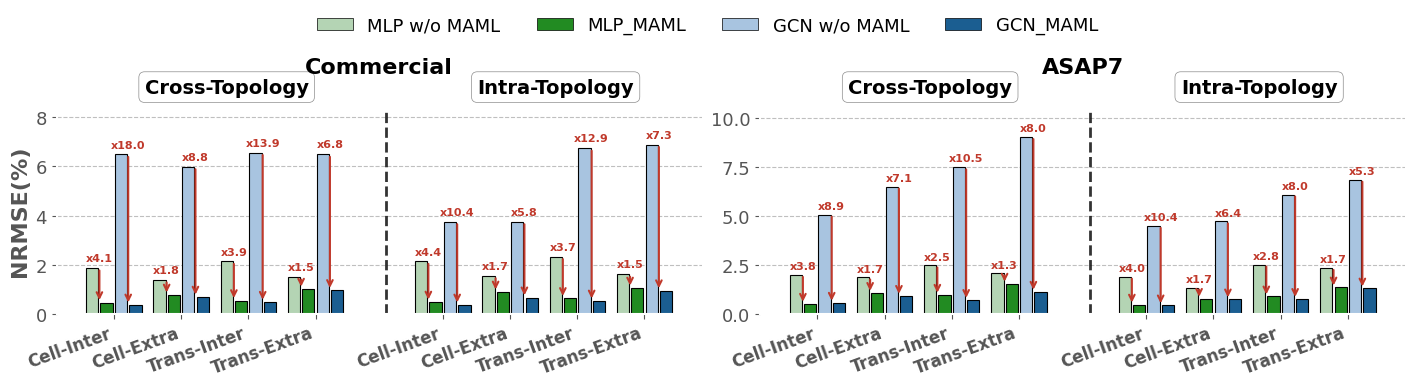

Saved: ./result_summary/gcn_single_arch_analysis_test/pdk_geomean_summary_combined.png

GEOMEAN NRMSE SUMMARY
PDK          Scenario           DataType     Mode               AADAM   MLP_MAML   GCN_Base   GCN_MAML
----------------------------------------------------------------------------------------------------
Commercial   Cross-Topology     cell         interpolation       1.87       0.46       6.49       0.36
Commercial   Cross-Topology     cell         extrapolation       1.38       0.77       5.99       0.68
Commercial   Cross-Topology     transition   interpolation       2.13       0.54       6.56       0.47
Commercial   Cross-Topology     transition   extrapolation       1.49       1.01       6.49       0.95
Commercial   Intra-Topology     cell         interpolation       2.13       0.48       3.75       0.36
Commercial   Intra-Topology     cell         extrapolation       1.55       0.89       3.75       0.65
Commercial   Intra-Topology     transition   interpolation       2.3

In [55]:

from scipy.stats import gmean
from matplotlib.patches import Patch

# ============================================================================
# CONFIGURATION
# ============================================================================
FIG_WIDTH = 14.25       # 2x ACM double-column width
FIG_HEIGHT = 3.5
BAR_WIDTH = 0.12
GROUP_PAD = 0.08
SECTION_GAP = 0.5
Y_HEADROOM = 1.5       # extra space above tallest bar
EXP_LABEL_OFFSET = 8   # pixels above top of axes

TITLE_FONTSIZE=16

model_order = ['AADAM', 'MLP_MAML', 'GCN_Baseline', 'GCN_MAML']
model_colors = {
    'AADAM': '#b4d4b4',
    'MLP_MAML': '#228b22',
    'GCN_Baseline': '#A8C4E0',
    'GCN_MAML': '#1B5E91',
}
model_display_names = {
    'AADAM': 'MLP w/o MAML',
    'MLP_MAML': 'MLP_MAML',
    'GCN_Baseline': 'GCN w/o MAML',
    'GCN_MAML': 'GCN_MAML',
}
ratio_pairs = [(0, 1), (2, 3)]

experiments = [
    ('topology_agnostic', 'Cross-Topology'),
    ('intra_topology', 'Intra-Topology'),
]
groups = [
    ('Cell', 'interpolation', 'Cell-Inter'),
    ('Cell', 'extrapolation', 'Cell-Extra'),
    ('Trans', 'interpolation', 'Trans-Inter'),
    ('Trans', 'extrapolation', 'Trans-Extra'),
]
pdk_list = [('TSMC', 'Commercial'), ('ASAP7', 'ASAP7')]

n_groups = len(groups)
n_models = len(model_order)
n_experiments = len(experiments)
group_width = n_models * BAR_WIDTH + GROUP_PAD
section_width = n_groups * group_width

# ============================================================================
# PLOTTING
# ============================================================================
plt.style.use('ggplot')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, FIG_HEIGHT))

geomean_summary = {pdk: {} for pdk, _ in pdk_list}

for ax_idx, (pdk, pdk_label) in enumerate(pdk_list):
    ax = axes[ax_idx]

    gcn_maml_df = gcn_maml_df_dict.get(pdk)
    gcn_baseline_df = gcn_baseline_df_dict.get(pdk) if gcn_baseline_df_dict else None
    mlp_df = mlp_df_dict.get(pdk)

    max_val = 0
    section_centers = []
    geomean_positions = {}

    for e_idx, (experiment, exp_label) in enumerate(experiments):
        section_start = e_idx * (section_width + SECTION_GAP)
        section_centers.append(section_start + section_width / 2)

        for g_idx, (data_type_short, mode, group_label) in enumerate(groups):
            data_type = 'cell' if data_type_short == 'Cell' else 'transition'

            for m_idx, model in enumerate(model_order):
                nrmse_values = []

                if model == 'AADAM' and mlp_df is not None:
                    filtered = mlp_df[
                        (mlp_df['model_type'] == 'AADAM') &
                        (mlp_df['data_type'] == data_type) &
                        (mlp_df['mode'] == mode) &
                        (mlp_df['iterations'] == aadam_iter)
                    ]
                    if 'topology' in mlp_df.columns:
                        filtered = filtered[filtered['topology'] == experiment]
                    elif 'experiment' in mlp_df.columns:
                        filtered = filtered[filtered['experiment'] == experiment]
                    nrmse_values = filtered['NRMSE'].dropna().tolist()

                elif model == 'MLP_MAML' and mlp_df is not None:
                    filtered = mlp_df[
                        (mlp_df['model_type'] == 'MLP_MAML') &
                        (mlp_df['data_type'] == data_type) &
                        (mlp_df['mode'] == mode)
                    ]
                    if 'topology' in mlp_df.columns:
                        filtered = filtered[filtered['topology'] == experiment]
                    elif 'experiment' in mlp_df.columns:
                        filtered = filtered[filtered['experiment'] == experiment]
                    if 'iterations' in mlp_df.columns:
                        filtered = filtered[filtered['iterations'] == mlp_maml_iter]
                    nrmse_values = filtered['NRMSE'].dropna().tolist()

                elif model == 'GCN_Baseline' and gcn_baseline_df is not None:
                    filtered = gcn_baseline_df[
                        (gcn_baseline_df['data_type'] == data_type) &
                        (gcn_baseline_df['mode'] == mode) &
                        (gcn_baseline_df['training_type'] == 'baseline')
                    ]
                    if 'pooling' in gcn_baseline_df.columns:
                        filtered = filtered[filtered['pooling'] == 'mean']
                    if 'experiment' in gcn_baseline_df.columns:
                        filtered = filtered[filtered['experiment'] == experiment]
                    if 'graph_mode' in gcn_baseline_df.columns:
                        filtered = filtered[filtered['graph_mode'] == 'full_graph']
                    nrmse_values = filtered['NRMSE'].dropna().tolist()

                elif model == 'GCN_MAML' and gcn_maml_df is not None:
                    expected_pooling = 'output' if data_type == 'transition' else 'mean'
                    filtered = gcn_maml_df[
                        (gcn_maml_df['data_type'] == data_type) &
                        (gcn_maml_df['mode'] == mode) &
                        (gcn_maml_df['training_type'] == 'maml') &
                        (gcn_maml_df['pooling'] == expected_pooling)
                    ]
                    if 'experiment' in gcn_maml_df.columns:
                        filtered = filtered[filtered['experiment'] == experiment]
                    if 'graph_mode' in gcn_maml_df.columns:
                        filtered = filtered[filtered['graph_mode'] == 'stage_aware']
                    if 'innerdiv' in gcn_maml_df.columns:
                        filtered = filtered[filtered['innerdiv'] == sa_innerdiv]
                    if 'meta' in gcn_maml_df.columns:
                        filtered = filtered[filtered['meta'] == sa_meta]
                    nrmse_values = filtered['NRMSE'].dropna().tolist()

                geomean_val = gmean(nrmse_values) if len(nrmse_values) > 0 else np.nan
                x_pos = section_start + g_idx * group_width + m_idx * BAR_WIDTH
                geomean_positions[(e_idx, g_idx, m_idx)] = (x_pos, geomean_val)

                geomean_summary[pdk].setdefault(experiment, {}) \
                    .setdefault(data_type, {}).setdefault(mode, {})[model] = geomean_val

                if not np.isnan(geomean_val):
                    ax.bar(x_pos, geomean_val, width=BAR_WIDTH * 0.85,
                            color=model_colors[model], edgecolor='black', linewidth=0.8)
                    max_val = max(max_val, geomean_val)

    # ---- Ratio arrows ----
    for e_idx in range(n_experiments):
        for g_idx in range(n_groups):
            for base_idx, maml_idx in ratio_pairs:
                base_key = (e_idx, g_idx, base_idx)
                maml_key = (e_idx, g_idx, maml_idx)
                if base_key not in geomean_positions or maml_key not in geomean_positions:
                    continue
                base_x, base_val = geomean_positions[base_key]
                maml_x, maml_val = geomean_positions[maml_key]
                if np.isnan(base_val) or np.isnan(maml_val) or maml_val <= 0:
                    continue

                ratio = base_val / maml_val
                arrow_x = (base_x + maml_x) / 2
                ax.annotate('', xy=(arrow_x, maml_val + 0.1),
                    xytext=(arrow_x, base_val - 0.1),
                    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5,
                                    shrinkA=0, shrinkB=0))
                ax.text(arrow_x, base_val + 0.2, f'x{ratio:.1f}',
                    fontsize=8, fontweight='bold', color='#C0392B',
                    va='bottom', ha='center')

    # ---- Vertical divider ----
    actual_bar_area_end = (n_groups - 1) * group_width + n_models * BAR_WIDTH
    second_section_start = section_width + SECTION_GAP
    divider_x = (actual_bar_area_end + second_section_start) / 2
    ax.axvline(x=divider_x, color='black', linestyle='--', linewidth=2.0, alpha=0.8)

    # ---- X-axis labels ----
    all_group_centers = []
    all_group_labels = []
    for e_idx in range(n_experiments):
        section_start = e_idx * (section_width + SECTION_GAP)
        for g_idx in range(n_groups):
            center = section_start + g_idx * group_width + (n_models - 1) * BAR_WIDTH / 2
            all_group_centers.append(center)
            all_group_labels.append(groups[g_idx][2])
    ax.set_xticks(all_group_centers)
    ax.set_xticklabels(all_group_labels, fontsize=12, fontweight='bold', rotation=20, ha='right')

    # ---- Y-axis ----
    ax.set_ylim(0, max_val + Y_HEADROOM)
    ax.set_axisbelow(True)
    ax.grid(True, alpha=0.5, axis='y', linestyle='--', linewidth=0.8, color='gray')
    ax.tick_params(axis='y', labelsize=13)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if ax_idx == 0:
        ax.set_ylabel('NRMSE(%)', fontsize=16, fontweight='bold')

    # ---- Title & experiment labels ----
    ax.set_title(pdk_label, fontsize=TITLE_FONTSIZE, fontweight='bold', pad=25)
    for e_idx, (experiment, exp_label) in enumerate(experiments):
        ax.annotate(exp_label, xy=(section_centers[e_idx], max_val + Y_HEADROOM),
            xycoords='data', xytext=(0, EXP_LABEL_OFFSET), textcoords='offset points',
            fontsize=14, fontweight='bold', ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                        edgecolor='gray', alpha=0.9))

# ---- Legend ----
legend_elements = [Patch(facecolor=model_colors[m], edgecolor='black',
                            label=model_display_names[m]) for m in model_order]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=13,
            bbox_to_anchor=(0.5, 1.12), frameon=False)

plt.tight_layout()
output_path = os.path.join(output_dir, 'pdk_geomean_summary_combined.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {output_path}")

# ---- Print summary table ----
print("\n" + "=" * 80)
print("GEOMEAN NRMSE SUMMARY")
print("=" * 80)
exp_display = {'topology_agnostic': 'Cross-Topology', 'intra_topology': 'Intra-Topology'}
pdk_display = {'TSMC': 'Commercial', 'ASAP7': 'ASAP7'}
print(f"{'PDK':<12} {'Scenario':<18} {'DataType':<12} {'Mode':<15} {'AADAM':>8} {'MLP_MAML':>10} {'GCN_Base':>10} {'GCN_MAML':>10}")
print("-" * 100)
for pdk in ['TSMC', 'ASAP7']:
    for exp in ['topology_agnostic', 'intra_topology']:
        for dtype in ['cell', 'transition']:
            for mode in ['interpolation', 'extrapolation']:
                vals = geomean_summary.get(pdk, {}).get(exp, {}).get(dtype, {}).get(mode, {})
                if vals:
                    print(f"{pdk_display[pdk]:<12} {exp_display[exp]:<18} {dtype:<12} {mode:<15} "
                            f"{vals.get('AADAM', np.nan):>8.2f} {vals.get('MLP_MAML', np.nan):>10.2f} "
                            f"{vals.get('GCN_Baseline', np.nan):>10.2f} {vals.get('GCN_MAML', np.nan):>10.2f}")
print("=" * 80)

In [2]:
from scipy.stats import gmean

# ============================================================================
# Extract GeoMean RMSE (same filtering as the plot, but pulling RMSE column)
# ============================================================================

rmse_summary = {}

for pdk in ['TSMC', 'ASAP7']:
    rmse_summary[pdk] = {}
    s_gcn_maml = gcn_maml_df_dict.get(pdk)
    s_gcn_base = gcn_baseline_df_dict.get(pdk) if gcn_baseline_df_dict else None
    s_mlp = mlp_df_dict.get(pdk)

    for exp in ['topology_agnostic', 'intra_topology']:
        rmse_summary[pdk][exp] = {}
        for dtype in ['cell', 'transition']:
            rmse_summary[pdk][exp][dtype] = {}
            for mode in ['interpolation', 'extrapolation']:
                rmse_vals = {}

                # AADAM
                if s_mlp is not None:
                    f = s_mlp[(s_mlp['model_type'] == 'AADAM') &
                              (s_mlp['data_type'] == dtype) &
                              (s_mlp['mode'] == mode) &
                              (s_mlp['iterations'] == args.aadam_iter)]
                    if 'topology' in s_mlp.columns:
                        f = f[f['topology'] == exp]
                    elif 'experiment' in s_mlp.columns:
                        f = f[f['experiment'] == exp]
                    vals = f['RMSE'].dropna().tolist()
                    rmse_vals['AADAM'] = gmean(vals) if len(vals) > 0 else np.nan

                # MLP_MAML
                if s_mlp is not None:
                    f = s_mlp[(s_mlp['model_type'] == 'MLP_MAML') &
                              (s_mlp['data_type'] == dtype) &
                              (s_mlp['mode'] == mode)]
                    if 'topology' in s_mlp.columns:
                        f = f[f['topology'] == exp]
                    elif 'experiment' in s_mlp.columns:
                        f = f[f['experiment'] == exp]
                    if 'iterations' in s_mlp.columns:
                        f = f[f['iterations'] == args.mlp_maml_iter]
                    vals = f['RMSE'].dropna().tolist()
                    rmse_vals['MLP_MAML'] = gmean(vals) if len(vals) > 0 else np.nan

                # GCN_Baseline
                if s_gcn_base is not None:
                    f = s_gcn_base[(s_gcn_base['data_type'] == dtype) &
                                   (s_gcn_base['mode'] == mode) &
                                   (s_gcn_base['training_type'] == 'baseline')]
                    if 'pooling' in s_gcn_base.columns:
                        f = f[f['pooling'] == 'mean']
                    if 'experiment' in s_gcn_base.columns:
                        f = f[f['experiment'] == exp]
                    if 'graph_mode' in s_gcn_base.columns:
                        f = f[f['graph_mode'] == 'full_graph']
                    vals = f['RMSE'].dropna().tolist()
                    rmse_vals['GCN_Baseline'] = gmean(vals) if len(vals) > 0 else np.nan

                # GCN_MAML
                if s_gcn_maml is not None:
                    expected_pooling = 'output' if dtype == 'transition' else 'mean'
                    f = s_gcn_maml[(s_gcn_maml['data_type'] == dtype) &
                                   (s_gcn_maml['mode'] == mode) &
                                   (s_gcn_maml['training_type'] == 'maml') &
                                   (s_gcn_maml['pooling'] == expected_pooling)]
                    if 'experiment' in s_gcn_maml.columns:
                        f = f[f['experiment'] == exp]
                    if 'graph_mode' in s_gcn_maml.columns:
                        f = f[f['graph_mode'] == 'stage_aware']
                    if 'innerdiv' in s_gcn_maml.columns:
                        f = f[f['innerdiv'] == args.sa_innerdiv]
                    if 'meta' in s_gcn_maml.columns:
                        f = f[f['meta'] == args.sa_meta]
                    vals = f['RMSE'].dropna().tolist()
                    rmse_vals['GCN_MAML'] = gmean(vals) if len(vals) > 0 else np.nan

                rmse_summary[pdk][exp][dtype][mode] = rmse_vals

# ============================================================================
# Print RMSE in ps (TSMC x1000 because stored in ns)
# ============================================================================

for pdk, pdk_label, scale in [('TSMC', 'Commercial 28nm', 1000.0),
                               ('ASAP7', 'ASAP7', 1.0)]:
    unit_note = '(ns->ps x1000)' if scale == 1000.0 else '(already ps)'
    print(f"\n{'='*70}")
    print(f"  {pdk_label}  {unit_note}")
    print(f"{'='*70}")

    rs = rmse_summary[pdk]

    # ---- Per experiment, per data type, geomean inter+extra ----
    for exp, exp_label in [('topology_agnostic', 'Cross-Topology'),
                            ('intra_topology', 'Intra-Topology')]:
        print(f"\n  --- {exp_label} ---")
        for dtype, dtype_label in [('cell', 'Cell Delay'), ('transition', 'Output Transition')]:
            inter = rs.get(exp, {}).get(dtype, {}).get('interpolation', {})
            extra = rs.get(exp, {}).get(dtype, {}).get('extrapolation', {})

            for model in ['AADAM', 'MLP_MAML', 'GCN_Baseline', 'GCN_MAML']:
                v_inter = inter.get(model, np.nan) * scale
                v_extra = extra.get(model, np.nan) * scale
                print(f"    {model:<15s}: interp={v_inter:.2f}ps  extrap={v_extra:.2f}ps")

            # Ratios relative to GCN_MAML
            gcn_maml_inter = inter.get('GCN_MAML', np.nan) * scale
            gcn_maml_extra = extra.get('GCN_MAML', np.nan) * scale
            print(f"    --- Ratios vs GCN_MAML ({gcn_maml_inter:.2f}ps / {gcn_maml_extra:.2f}ps) ---")
            for model in ['AADAM', 'MLP_MAML', 'GCN_Baseline']:
                v_inter = inter.get(model, np.nan) * scale
                v_extra = extra.get(model, np.nan) * scale
                r_inter = v_inter / gcn_maml_inter if gcn_maml_inter > 0 else np.nan
                r_extra = v_extra / gcn_maml_extra if gcn_maml_extra > 0 else np.nan
                print(f"      {model:<15s}: x{r_inter:.1f} / x{r_extra:.1f}")

    # ---- Combined cross+intra per data type ----
    print(f"\n  --- Combined (GeoMean cross+intra) ---")
    for dtype, dtype_label in [('cell', 'Cell Delay'), ('transition', 'Output Transition')]:
        for model in ['AADAM', 'MLP_MAML', 'GCN_Baseline', 'GCN_MAML']:
            vals_inter, vals_extra = [], []
            for exp in ['topology_agnostic', 'intra_topology']:
                vi = rs.get(exp, {}).get(dtype, {}).get('interpolation', {}).get(model, np.nan)
                ve = rs.get(exp, {}).get(dtype, {}).get('extrapolation', {}).get(model, np.nan)
                if not np.isnan(vi): vals_inter.append(vi * scale)
                if not np.isnan(ve): vals_extra.append(ve * scale)
            gm_inter = gmean(vals_inter) if vals_inter else np.nan
            gm_extra = gmean(vals_extra) if vals_extra else np.nan
            print(f"    {dtype_label} | {model:<15s}: interp={gm_inter:.2f}ps  extrap={gm_extra:.2f}ps")

NameError: name 'gcn_maml_df_dict' is not defined

In [1]:
# Extract values for LaTeX (Commercial / TSMC only)
pdk = 'TSMC'
s = geomean_summary[pdk]

for exp, exp_label in [('topology_agnostic', 'Cross-Topology'),
                        ('intra_topology', 'Intra-Topology')]:
    print(f"\n=== {exp_label} ===")
    for dtype, dtype_label in [('cell', 'Cell Delay'), ('transition', 'Output Transition')]:
        for mode in ['interpolation', 'extrapolation']:
            vals = s.get(exp, {}).get(dtype, {}).get(mode, {})
            aadam    = vals.get('AADAM', np.nan)
            mlp_maml = vals.get('MLP_MAML', np.nan)
            gcn_base = vals.get('GCN_Baseline', np.nan)
            gcn_maml = vals.get('GCN_MAML', np.nan)

            mlp_ratio = aadam / mlp_maml if mlp_maml > 0 else np.nan
            gcn_ratio = gcn_base / gcn_maml if gcn_maml > 0 else np.nan

            print(f"  {dtype_label} {mode}:")
            print(f"    MLP:  {aadam:.2f}% -> {mlp_maml:.2f}%  ({mlp_ratio:.1f}x)")
            print(f"    GCN:  {gcn_base:.2f}% -> {gcn_maml:.2f}%  ({gcn_ratio:.1f}x)")

NameError: name 'geomean_summary' is not defined

In [11]:
output_dir=args.output_dir
aadam_iter=args.aadam_iter
mlp_maml_iter=args.mlp_maml_iter
sa_innerdiv = args.sa_innerdiv
sa_meta=args.sa_meta
arch=args.arch

/tmp/ipykernel_2697130/4294775941.py:332: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


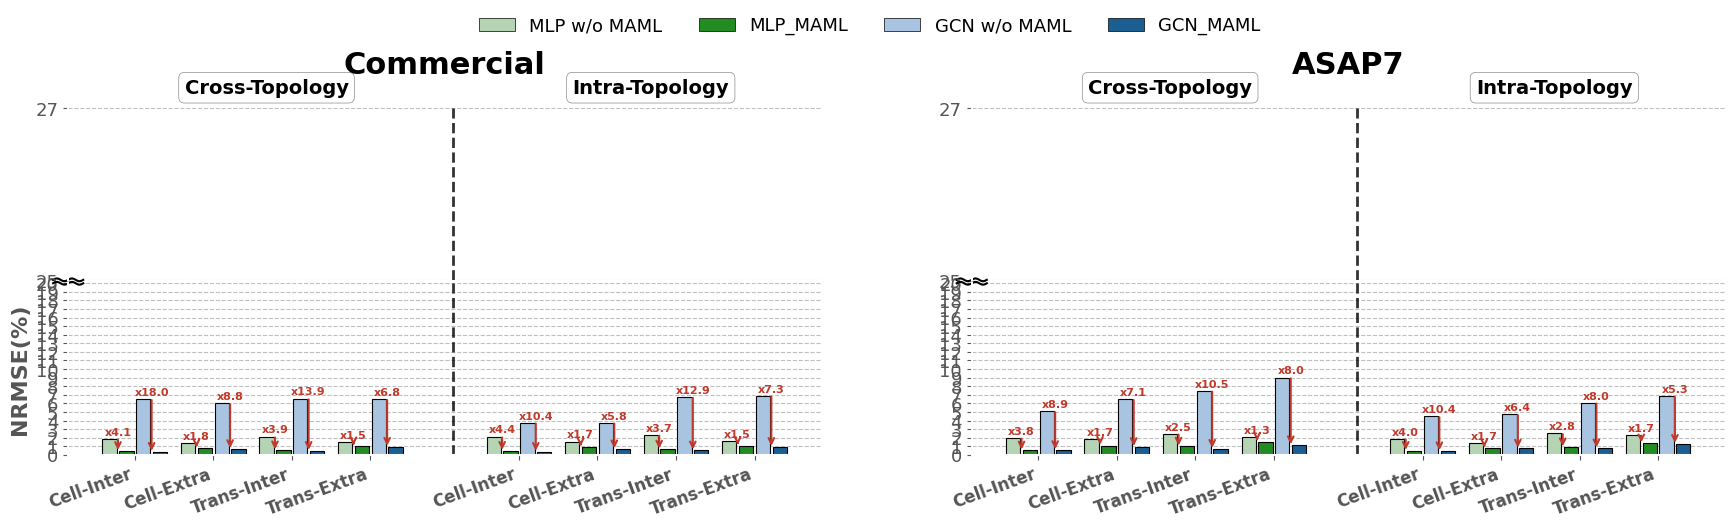

In [52]:
from scipy.stats import gmean
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FixedLocator
from matplotlib.patches import Patch
import numpy as np

# ============================================================================
# CONFIGURATION - adjust these to taste
# ============================================================================

# --- Broken axis ---
BREAK_LOWER = 20.0     # lower axis shows 0 → BREAK_LOWER
BREAK_UPPER = 25.0      # upper axis shows BREAK_UPPER → auto max
COMPRESSION = 1.2      # headroom above tallest bar in upper region
HEIGHT_RATIO_UPPER = 1.0
HEIGHT_RATIO_LOWER = 1.0

# --- Wavy break indicators ---
WAVE_AMP_AXIS = 0.008      # amplitude for y-axis wave (axes coords)
WAVE_AMP_BAR = 0.10         # amplitude for bar waves (data coords, NRMSE units)
WAVE_N_PERIODS_AXIS = 2     # number of squiggles on axis
WAVE_N_PERIODS_BAR = 3      # number of squiggles on bars
WAVE_MASK_THICKNESS = 0.15  # white mask thickness around bar break (data coords)

# --- Figure size ---
FIG_WIDTH = 21.375
FIG_HEIGHT = 4.5

# --- Bar layout ---
BAR_WIDTH = 0.12
GROUP_PAD = 0.08
SECTION_GAP = 0.5

# --- Experiment label placement ---
EXP_LABEL_Y_OFFSET = 0.8   # how far above upper_max to place labels (data coords)

# ============================================================================
# MODEL / EXPERIMENT / GROUP DEFINITIONS
# ============================================================================

model_order = ['AADAM', 'MLP_MAML', 'GCN_Baseline', 'GCN_MAML']
model_colors = {
    'AADAM': '#b4d4b4',
    'MLP_MAML': '#228b22',
    'GCN_Baseline': '#A8C4E0',
    'GCN_MAML': '#1B5E91',
}
model_display_names = {
    'AADAM': 'MLP w/o MAML',
    'MLP_MAML': 'MLP_MAML',
    'GCN_Baseline': 'GCN w/o MAML',
    'GCN_MAML': 'GCN_MAML',
}
ratio_pairs = [(0, 1), (2, 3)]

experiments = [
    ('topology_agnostic', 'Cross-Topology'),
    ('intra_topology', 'Intra-Topology'),
]
groups = [
    ('Cell', 'interpolation', 'Cell-Inter'),
    ('Cell', 'extrapolation', 'Cell-Extra'),
    ('Trans', 'interpolation', 'Trans-Inter'),
    ('Trans', 'extrapolation', 'Trans-Extra'),
]
pdk_list = [('TSMC', 'Commercial'), ('ASAP7', 'ASAP7')]

# ============================================================================
# HELPER: draw wavy break on y-axis
# ============================================================================
def draw_axis_wave(ax, y_frac, amp, n_periods, n_pts=80):
    """Draw a wavy line across the y-axis spine at y_frac (in axes coords)."""
    wx = np.linspace(-0.02, 0.02, n_pts)
    wy = y_frac + amp * np.sin(wx / 0.04 * 2 * np.pi * n_periods)
    ax.plot(wx, wy, transform=ax.transAxes, color='k', clip_on=False, linewidth=1.5)

# ============================================================================
# HELPER: draw wavy break on a bar
# ============================================================================
def draw_bar_wave(ax_lower, ax_upper, x_pos, bar_w, break_y, amp, n_periods, mask_h):
    """Draw wavy line across a bar at the break point, with white mask."""
    half_w = bar_w / 2
    wx = np.linspace(x_pos - half_w, x_pos + half_w, 60)
    wy = break_y + amp * np.sin(
        (wx - wx[0]) / (wx[-1] - wx[0]) * 2 * np.pi * n_periods
    )
    for ax in [ax_lower, ax_upper]:
        ax.fill_between(wx, break_y - mask_h, break_y + mask_h,
                        color='white', zorder=5)
        ax.plot(wx, wy, color='black', linewidth=1.2, clip_on=False, zorder=6)

# ============================================================================
# PLOTTING
# ============================================================================

plt.style.use('ggplot')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))
gs = gridspec.GridSpec(2, 2, height_ratios=[HEIGHT_RATIO_UPPER, HEIGHT_RATIO_LOWER], hspace=0.02)

all_geomean_data = {pdk: [] for pdk, _ in pdk_list}
geomean_summary = {pdk: {} for pdk, _ in pdk_list}

n_groups = len(groups)
n_models = len(model_order)
n_experiments = len(experiments)
group_width = n_models * BAR_WIDTH + GROUP_PAD
section_width = n_groups * group_width

for ax_idx, (pdk, pdk_label) in enumerate(pdk_list):
    ax_upper = fig.add_subplot(gs[0, ax_idx])
    ax_lower = fig.add_subplot(gs[1, ax_idx], sharex=ax_upper)

    gcn_maml_df = gcn_maml_df_dict.get(pdk)
    gcn_baseline_df = gcn_baseline_df_dict.get(pdk) if gcn_baseline_df_dict else None
    mlp_df = mlp_df_dict.get(pdk)

    max_val = 0
    section_centers = []
    geomean_positions = {}

    # ---- Compute & draw bars ----
    for e_idx, (experiment, exp_label) in enumerate(experiments):
        section_start = e_idx * (section_width + SECTION_GAP)
        section_centers.append(section_start + section_width / 2)

        for g_idx, (data_type_short, mode, group_label) in enumerate(groups):
            data_type = 'cell' if data_type_short == 'Cell' else 'transition'

            for m_idx, model in enumerate(model_order):
                nrmse_values = []

                if model == 'AADAM' and mlp_df is not None:
                    filtered = mlp_df[
                        (mlp_df['model_type'] == 'AADAM') &
                        (mlp_df['data_type'] == data_type) &
                        (mlp_df['mode'] == mode) &
                        (mlp_df['iterations'] == aadam_iter)
                    ]
                    if 'topology' in mlp_df.columns:
                        filtered = filtered[filtered['topology'] == experiment]
                    elif 'experiment' in mlp_df.columns:
                        filtered = filtered[filtered['experiment'] == experiment]
                    nrmse_values = filtered['NRMSE'].dropna().tolist()

                elif model == 'MLP_MAML' and mlp_df is not None:
                    filtered = mlp_df[
                        (mlp_df['model_type'] == 'MLP_MAML') &
                        (mlp_df['data_type'] == data_type) &
                        (mlp_df['mode'] == mode)
                    ]
                    if 'topology' in mlp_df.columns:
                        filtered = filtered[filtered['topology'] == experiment]
                    elif 'experiment' in mlp_df.columns:
                        filtered = filtered[filtered['experiment'] == experiment]
                    if 'iterations' in mlp_df.columns:
                        filtered = filtered[filtered['iterations'] == mlp_maml_iter]
                    nrmse_values = filtered['NRMSE'].dropna().tolist()

                elif model == 'GCN_Baseline' and gcn_baseline_df is not None:
                    filtered = gcn_baseline_df[
                        (gcn_baseline_df['data_type'] == data_type) &
                        (gcn_baseline_df['mode'] == mode) &
                        (gcn_baseline_df['training_type'] == 'baseline')
                    ]
                    if 'pooling' in gcn_baseline_df.columns:
                        filtered = filtered[filtered['pooling'] == 'mean']
                    if 'experiment' in gcn_baseline_df.columns:
                        filtered = filtered[filtered['experiment'] == experiment]
                    if 'graph_mode' in gcn_baseline_df.columns:
                        filtered = filtered[filtered['graph_mode'] == 'full_graph']
                    nrmse_values = filtered['NRMSE'].dropna().tolist()

                elif model == 'GCN_MAML' and gcn_maml_df is not None:
                    expected_pooling = 'output' if data_type == 'transition' else 'mean'
                    filtered = gcn_maml_df[
                        (gcn_maml_df['data_type'] == data_type) &
                        (gcn_maml_df['mode'] == mode) &
                        (gcn_maml_df['training_type'] == 'maml') &
                        (gcn_maml_df['pooling'] == expected_pooling)
                    ]
                    if 'experiment' in gcn_maml_df.columns:
                        filtered = filtered[filtered['experiment'] == experiment]
                    if 'graph_mode' in gcn_maml_df.columns:
                        filtered = filtered[filtered['graph_mode'] == 'stage_aware']
                    if 'innerdiv' in gcn_maml_df.columns:
                        filtered = filtered[filtered['innerdiv'] == sa_innerdiv]
                    if 'meta' in gcn_maml_df.columns:
                        filtered = filtered[filtered['meta'] == sa_meta]
                    nrmse_values = filtered['NRMSE'].dropna().tolist()

                geomean_val = gmean(nrmse_values) if len(nrmse_values) > 0 else np.nan
                x_pos = section_start + g_idx * group_width + m_idx * BAR_WIDTH
                geomean_positions[(e_idx, g_idx, m_idx)] = (x_pos, geomean_val)

                # Store summary
                geomean_summary[pdk].setdefault(experiment, {}) \
                    .setdefault(data_type, {}).setdefault(mode, {})[model] = geomean_val

                if not np.isnan(geomean_val):
                    bw = BAR_WIDTH * 0.85
                    ax_lower.bar(x_pos, geomean_val, width=bw,
                                 color=model_colors[model], edgecolor='black', linewidth=0.8)
                    if geomean_val > BREAK_LOWER:
                        ax_upper.bar(x_pos, geomean_val, width=bw,
                                     color=model_colors[model], edgecolor='black', linewidth=0.8)
                    max_val = max(max_val, geomean_val)
                    all_geomean_data[pdk].append((x_pos, geomean_val, model))

    # ---- Wavy break on bars that cross the break ----
    #for (x_pos, val, model) in all_geomean_data[pdk]:
    #    if val > BREAK_LOWER:
    #        draw_bar_wave(ax_lower, ax_upper, x_pos, BAR_WIDTH * 0.85,
    #                      BREAK_LOWER, WAVE_AMP_BAR, WAVE_N_PERIODS_BAR, WAVE_MASK_THICKNESS)

    # ---- Ratio arrows ----
    for e_idx in range(n_experiments):
        for g_idx in range(n_groups):
            for base_idx, maml_idx in ratio_pairs:
                base_key = (e_idx, g_idx, base_idx)
                maml_key = (e_idx, g_idx, maml_idx)
                if base_key not in geomean_positions or maml_key not in geomean_positions:
                    continue
                base_x, base_val = geomean_positions[base_key]
                maml_x, maml_val = geomean_positions[maml_key]
                if np.isnan(base_val) or np.isnan(maml_val) or maml_val <= 0:
                    continue

                ratio = base_val / maml_val
                arrow_x = (base_x + maml_x) / 2

                if base_val <= BREAK_LOWER and maml_val <= BREAK_LOWER:
                    ax_lower.annotate('', xy=(arrow_x, maml_val + 0.1),
                        xytext=(arrow_x, base_val - 0.1),
                        arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5, shrinkA=0, shrinkB=0))
                    ax_lower.text(arrow_x, base_val + 0.2, f'x{ratio:.1f}',
                        fontsize=8, fontweight='bold', color='#C0392B', va='bottom', ha='center')
                elif base_val > BREAK_LOWER and maml_val <= BREAK_LOWER:
                    ax_upper.plot([arrow_x, arrow_x], [base_val - 0.1, BREAK_UPPER],
                        color='#C0392B', lw=1.5, solid_capstyle='butt')
                    ax_lower.annotate('', xy=(arrow_x, maml_val + 0.1),
                        xytext=(arrow_x, BREAK_LOWER),
                        arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5, shrinkA=0, shrinkB=0))
                    ax_upper.text(arrow_x, base_val + 0.3, f'x{ratio:.1f}',
                        fontsize=8, fontweight='bold', color='#C0392B', va='bottom', ha='center')
                else:
                    ax_upper.annotate('', xy=(arrow_x, maml_val + 0.1),
                        xytext=(arrow_x, base_val - 0.1),
                        arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5, shrinkA=0, shrinkB=0))
                    ax_upper.text(arrow_x, base_val + 0.3, f'x{ratio:.1f}',
                        fontsize=8, fontweight='bold', color='#C0392B', va='bottom', ha='center')

    # ---- Vertical divider between Cross / Intra ----
    actual_bar_area_end = (n_groups - 1) * group_width + n_models * BAR_WIDTH
    second_section_start = section_width + SECTION_GAP
    divider_x = (actual_bar_area_end + second_section_start) / 2
    for ax in [ax_lower, ax_upper]:
        ax.axvline(x=divider_x, color='black', linestyle='--', linewidth=2.0, alpha=0.8)

    # ---- X-axis labels (lower only) ----
    all_group_centers = []
    all_group_labels = []
    for e_idx in range(n_experiments):
        section_start = e_idx * (section_width + SECTION_GAP)
        for g_idx in range(n_groups):
            center = section_start + g_idx * group_width + (n_models - 1) * BAR_WIDTH / 2
            all_group_centers.append(center)
            all_group_labels.append(groups[g_idx][2])
    ax_lower.set_xticks(all_group_centers)
    ax_lower.set_xticklabels(all_group_labels, fontsize=12, fontweight='bold', rotation=20, ha='right')
    plt.setp(ax_upper.get_xticklabels(), visible=False)

    # ---- Y-axis limits (the actual break) ----
    upper_max = max(max_val + COMPRESSION, BREAK_UPPER + 2)
    ax_lower.set_ylim(0, BREAK_LOWER)
    ax_upper.set_ylim(BREAK_UPPER, upper_max)

    # ---- Y-axis ticks ----
    lower_ticks = list[int](range(0, int(BREAK_LOWER) + 1))
    ax_lower.yaxis.set_major_locator(FixedLocator(lower_ticks))

    upper_tick_start = int(np.ceil(BREAK_UPPER))
    upper_ticks = list(range(upper_tick_start, int(upper_max) + 1, 2))
    ax_upper.yaxis.set_major_locator(FixedLocator(upper_ticks))

    # ---- Spine / grid styling ----
    for ax in [ax_lower, ax_upper]:
        ax.set_axisbelow(True)
        ax.grid(True, alpha=0.5, axis='y', linestyle='--', linewidth=0.8, color='gray')
        ax.tick_params(axis='y', labelsize=13)
        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
    ax_lower.spines['bottom'].set_visible(True)
    ax_lower.spines['bottom'].set_linewidth(1.5)
    ax_upper.spines['bottom'].set_visible(False)
    ax_upper.tick_params(axis='x', bottom=False)

    # ---- Y-axis label (left plot only) ----
    if ax_idx == 0:
        ax_lower.set_ylabel('NRMSE(%)', fontsize=16, fontweight='bold')

    # ---- PDK title ----
    ax_upper.set_title(pdk_label, fontsize=22, fontweight='bold', pad=25)

    # ---- Experiment section labels (above title area, no overlap) ----
    for e_idx, (experiment, exp_label) in enumerate(experiments):
        # Place in axes coords so it stays above the plot regardless of data
        x_data = section_centers[e_idx]
        ax_upper.annotate(exp_label, xy=(x_data, upper_max), xycoords='data',
            xytext=(0, 8), textcoords='offset points',
            fontsize=14, fontweight='bold', ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.9))

    # ---- Wavy break indicators on y-axis ----
    draw_axis_wave(ax_upper, y_frac=0.0, amp=WAVE_AMP_AXIS, n_periods=WAVE_N_PERIODS_AXIS)
    draw_axis_wave(ax_lower, y_frac=1.0, amp=WAVE_AMP_AXIS, n_periods=WAVE_N_PERIODS_AXIS)

# ---- Legend ----
legend_elements = [Patch(facecolor=model_colors[m], edgecolor='black',
                         label=model_display_names[m]) for m in model_order]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=13,
           bbox_to_anchor=(0.5, 1.12), frameon=False)

plt.tight_layout()
output_path = os.path.join(output_dir, 'pdk_geomean_summary_combined.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()